# AIT303 Assignment 1 — Aspect Extraction & Topic Modeling

**Author:** [Student Name]

This notebook performs aspect extraction on scraped Best Buy Bluetooth & Wireless Speaker reviews
using three topic modeling approaches:
- **LDA** (gensim LdaMulticore) — unsupervised
- **BERTopic** (all-MiniLM-L6-v2 embeddings) — unsupervised
- **CorEx** (anchored semi-supervised) — semi-supervised

**Pipeline:** Preprocessing → SpaCy Keyphrase Extraction → LDA/BERTopic → Aspect Restructuring → CorEx

## 1. Colab Setup & Data Loading

### ⚡ Colab Instructions
If running on Google Colab:
1. Upload the `data_asg/bestbuy/` folder to your Google Drive (as `data_asg/bestbuy/`)
2. Set `COLAB = True` in the config cell below
3. Run all cells — the notebook will mount your Drive

**First-run note:** The pip install cell downloads ~200MB of packages. Sentence-transformers
model (all-MiniLM-L6-v2, 80MB) downloads on first BERTopic use. Both cache after first run.

In [1]:
# ============================================
# CONFIGURATION
# ============================================
COLAB = True

if COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_DIR = '/content/drive/MyDrive/data_asg'
    BESTBUY_DIR = f'{DATA_DIR}/bestbuy'
    MODEL_DIR = f'{DATA_DIR}/models'
else:
    DATA_DIR = 'data_asg'
    BESTBUY_DIR = f'{DATA_DIR}/bestbuy'
    MODEL_DIR = 'models'

print(f"Running in {'COLAB' if COLAB else 'LOCAL'} mode")
print(f"Data directory: {DATA_DIR}")
print(f"Best Buy data:  {BESTBUY_DIR}")
print(f"Model directory: {MODEL_DIR}")

import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning, module='jupyter_client')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Running in COLAB mode
Data directory: /content/drive/MyDrive/data_asg
Best Buy data:  /content/drive/MyDrive/data_asg/bestbuy
Model directory: /content/drive/MyDrive/data_asg/models


In [2]:
# Install all required packages (Colab)
# gensim 4.4.0 cannot install on Python 3.14 - this notebook runs on Colab (Python 3.10)
!pip install gensim==4.4.0 spacy==3.8.0 bertopic==0.17.4 corextopic==1.1 pyLDAvis==3.4.1 umap-learn hdbscan curl-cffi
!pip install --upgrade jupyter-client
!python -m spacy download en_core_web_sm

import warnings
warnings.filterwarnings('ignore')

print("Package installation complete")

  Using cached https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.8.0/en_core_web_sm-3.8.0-py3-none-any.whl (12.8 MB)
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Package installation complete


In [3]:
# ============================================
# IMPORTS
# ============================================
import os
import re
import json
import random
import warnings
import pickle
warnings.filterwarnings('ignore')
warnings.filterwarnings('ignore', category=DeprecationWarning, module='jupyter_client')

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# NLP
import spacy

# LDA
from gensim.corpora import Dictionary
from gensim.models import LdaModel
from gensim.models.coherencemodel import CoherenceModel

# BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from bertopic import BERTopic

# CorEx
from corextopic import corextopic as ct

# LDA visualization
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

# Scikit-learn utilities
from sklearn.feature_extraction.text import CountVectorizer as SkCountVectorizer

# Web scraping (TLS impersonation for Best Buy hidden API)
from curl_cffi import requests as curl_requests

# Reproducibility
np.random.seed(42)
random.seed(42)

print("All imports loaded successfully")
print(f"pandas {pd.__version__}, numpy {np.__version__}, spaCy {spacy.__version__}")

All imports loaded successfully
pandas 2.2.2, numpy 1.26.4, spaCy 3.8.0


## 2. Load & Preprocess Reviews

In [4]:
# Load the consolidated reviews CSV
csv_path = f'{BESTBUY_DIR}/all_reviews.csv'
df = pd.read_csv(csv_path)

print(f"DataFrame shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"Missing values:\n{df.isnull().sum()}")
print(f"\nUnique products: {df['product_name'].nunique()}")
print(f"Total reviews:   {len(df)}")
print(f"\nFirst 3 rows:")
df.head(3)

DataFrame shape: (3199, 4)
Columns: ['product_name', 'review_text', 'rating', 'date']
Missing values:
product_name    0
review_text     0
rating          0
date            0
dtype: int64

Unique products: 37
Total reviews:   3199

First 3 rows:


,product_name,review_text,rating,date
0,Bose SoundLink Micro,"Color is nice, used inside house and outside h...",4,2026-05-30T20:23:17.000-05:00
1,Bose SoundLink Micro,⭐⭐⭐⭐⭐ Review for the Bose SoundLink Max\n\nThe...,5,2026-05-28T15:03:34.000-05:00
2,Bose SoundLink Micro,This speaker sounds great! It’s light weight a...,5,2026-05-24T06:37:41.000-05:00


In [5]:
# Load product metadata catalog
catalog_path = f'{BESTBUY_DIR}/products.json'
with open(catalog_path, 'r') as f:
    products = json.load(f)
products_df = pd.DataFrame(products)

print(f"Products in catalog: {len(products_df)}")
print(f"Columns: {list(products_df.columns)}")
products_df.head(5)

Products in catalog: 37
Columns: ['sku', 'name', 'review_count']


,sku,name,review_count
0,5892609,Bose SoundLink Micro,100
1,6472669,Bose SoundLink Flex,100
2,6509650,JBL Charge 5,100
3,6510260,JBL Xtreme 3,100
4,4601400,Beats Pill+,100


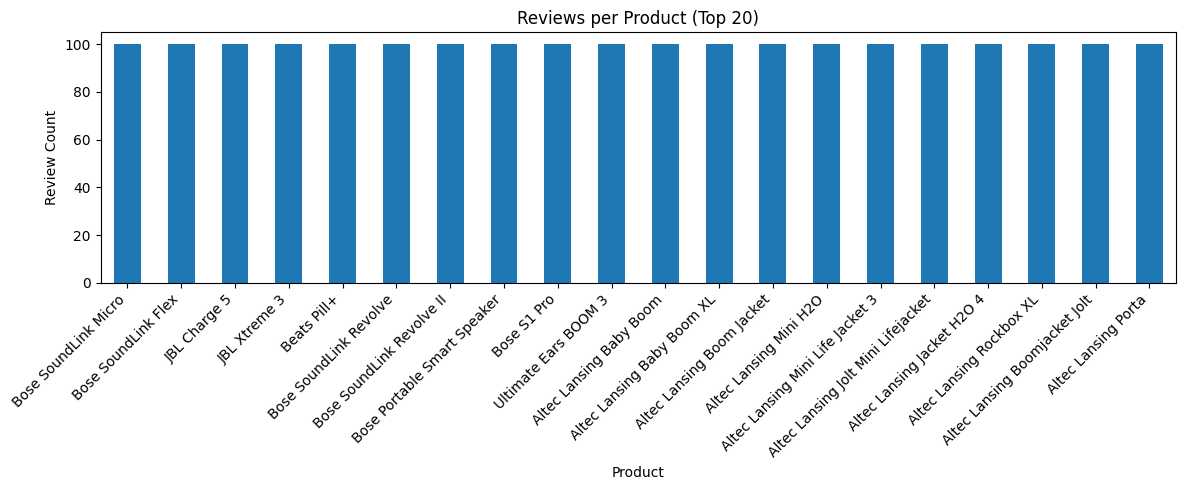

Min reviews per product: 20
Max reviews per product: 100
Mean reviews per product: 86.5
Products with >= 80 reviews: 28


In [6]:
# Reviews per product
review_counts = df['product_name'].value_counts()

plt.figure(figsize=(12, 5))
review_counts.head(20).plot(kind='bar')
plt.title('Reviews per Product (Top 20)')
plt.xlabel('Product')
plt.ylabel('Review Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"Min reviews per product: {review_counts.min()}")
print(f"Max reviews per product: {review_counts.max()}")
print(f"Mean reviews per product: {review_counts.mean():.1f}")
print(f"Products with >= 80 reviews: {(review_counts >= 80).sum()}")

### 2.1 Text Preprocessing — Clean Review Text

Reusing the `clean_text()` pipeline from Phase 1 (sentiment_analysis_preprocessing.ipynb):
lowercase → remove HTML → remove non-alpha → normalize whitespace (per D-24).
Product metadata is stored separately and NOT prepended to review text (per D-25).

In [7]:
def clean_text(text):
    """Clean raw review text: lowercase, remove HTML tags, remove non-alpha characters, normalize whitespace."""
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [8]:
# Apply Phase 1 preprocessing to review text
df['cleaned_review'] = df['review_text'].apply(clean_text)

# Verify cleaning
print("Before vs After Cleaning (sample):")
for i in range(3):
    print(f"\n--- Sample {i+1} ---")
    print(f"BEFORE: {df['review_text'].iloc[i][:150]}")
    print(f"AFTER:  {df['cleaned_review'].iloc[i][:150]}")

print(f"\nCleaned review length stats:")
print(df['cleaned_review'].str.len().describe())

# Filter out empty reviews after cleaning
empty_count = (df['cleaned_review'].str.len() == 0).sum()
print(f"\nEmpty reviews after cleaning: {empty_count} ({empty_count/len(df)*100:.1f}%)")

Before vs After Cleaning (sample):

--- Sample 1 ---
BEFORE: Color is nice, used inside house and outside house, used on the road driving, good quality sound, and does the job good
AFTER:  color is nice used inside house and outside house used on the road driving good quality sound and does the job good

--- Sample 2 ---
BEFORE: ⭐⭐⭐⭐⭐ Review for the Bose SoundLink Max

The Bose SoundLink Max is honestly one of the best portable speakers I’ve owned. The sound quality is powerfu
AFTER:  review for the bose soundlink max the bose soundlink max is honestly one of the best portable speakers i ve owned the sound quality is powerful clear 

--- Sample 3 ---
BEFORE: This speaker sounds great! It’s light weight and easy to connect to all my blue tooth devices.
AFTER:  this speaker sounds great it s light weight and easy to connect to all my blue tooth devices

Cleaned review length stats:
count    3199.000000
mean      181.786496
std       335.105522
min         4.000000
25%        66.000000
50

In [9]:
# Tokenize cleaned reviews for gensim LDA input
# df['tokens'] = df['cleaned_review'].str.split()
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
df['tokens'] = df['cleaned_review'].apply(
    lambda x: [w for w in x.split() if w not in ENGLISH_STOP_WORDS and len(w) > 1]
)

# Filter short reviews (minimum 3 tokens for meaningful topic contribution)
df_valid = df[df['tokens'].apply(len) >= 3].copy()

print(f"Reviews with >= 3 tokens: {len(df_valid)} / {len(df)}")
print(f"Removed {len(df) - len(df_valid)} very short reviews")

Reviews with >= 3 tokens: 3185 / 3199
Removed 14 very short reviews


In [10]:
# Save preprocessed DataFrame for downstream use
preprocessed_path = f'{BESTBUY_DIR}/preprocessed_reviews.csv'
df_valid.to_csv(preprocessed_path, index=False)
print(f"Preprocessed data saved to: {preprocessed_path}")
print(f"Shape: {df_valid.shape}")

Preprocessed data saved to: /content/drive/MyDrive/data_asg/bestbuy/preprocessed_reviews.csv
Shape: (3185, 6)


## 3. Keyphrase Extraction with SpaCy

Extracting meaningful keyphrases (noun chunks and named entities) from the cleaned review text
using SpaCy's linguistic annotations. These keyphrases serve as candidate aspect terms
for downstream topic modeling.

### ⏱ First-Run Note
The cell below downloads the `en_core_web_sm` model (~12MB). This is a one-time download
that caches after the first run.

In [11]:
# ===== SpaCy Keyphrase Extraction =====
# Extract noun chunks and named entities as candidate aspect terms
nlp = spacy.load('en_core_web_sm')

def extract_keyphrases(text):
    """Extract noun chunks and named entities as aspect-relevant keyphrases."""
    doc = nlp(text)
    keyphrases = set()
    
    # Noun chunks (e.g., "battery life", "sound quality")
    for chunk in doc.noun_chunks:
        phrase = chunk.text.lower().strip()
        if len(phrase.split()) <= 4:  # max 4 words
            keyphrases.add(phrase)
    
    # Named entities (e.g., "JBL", "Bose")
    for ent in doc.ents:
        if ent.label_ in ['ORG', 'PRODUCT', 'EVENT']:
            keyphrases.add(ent.text.lower().strip())
    
    return list(keyphrases)


# Test on a sample
sample = df['cleaned_review'].iloc[0]
print(f"Sample text: {sample[:200]}...")
print(f"Keyphrases: {extract_keyphrases(sample)}")


Sample text: color is nice used inside house and outside house used on the road driving good quality sound and does the job good...
Keyphrases: ['the road', 'color', 'outside house', 'the job', 'house', 'good quality sound']


In [12]:
# ===== Apply Keyphrase Extraction =====
print("Extracting keyphrases from all reviews (this may take a few minutes)...")
df['keyphrases'] = df['cleaned_review'].apply(extract_keyphrases)
print(f"Keyphrases extracted for {len(df)} reviews")
print(f"\nSample keyphrases:")
print(df[['cleaned_review', 'keyphrases']].head(3))


Extracting keyphrases from all reviews (this may take a few minutes)...
Keyphrases extracted for 3199 reviews

Sample keyphrases:
                                      cleaned_review  \
0  color is nice used inside house and outside ho...   
1  review for the bose soundlink max the bose sou...   
2  this speaker sounds great it s light weight an...   

                                          keyphrases  
0  [the road, color, outside house, the job, hous...  
1  [durable stylish, review, the bose soundlink m...  
2                   [light weight, this speaker, it]  


## 4. Unsupervised Aspect Extraction — LDA Topic Modeling

Training LDA with LdaMulticore (multi-core parallelization).
Grid search over 6-10 topic counts, selecting the best via C_v topic coherence (D-27).
Targeting 6-10 interpretable topics covering product aspects (D-29).

In [13]:
# ===== Build gensim Dictionary and Corpus =====
# Prepare tokenized reviews for gensim
tokenized_reviews = df['tokens'].tolist()

# Build dictionary — maps token → integer ID
dictionary = Dictionary(tokenized_reviews)

# Filter extremes: remove words in <5 docs, keep words in <=50% of all docs
dictionary.filter_extremes(no_below=5, no_above=0.5)

# Create bag-of-words corpus: list of (token_id, frequency) vectors
corpus = [dictionary.doc2bow(tokens) for tokens in tokenized_reviews]

print(f"Dictionary size: {len(dictionary)} unique tokens")
print(f"Corpus size: {len(corpus)} documents")

Dictionary size: 1344 unique tokens
Corpus size: 3199 documents


In [14]:
# ===== LDA Grid Search — 6 to 10 Topics =====
topic_range = range(6, 11)
coherence_scores = {}
lda_models = {}

for k in topic_range:
    lda = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=k,
        chunksize=2000,
        passes=10,
        iterations=400,
        alpha='auto',
        eta='auto',
        random_state=42
    )
    cm = CoherenceModel(
        model=lda,
        texts=tokenized_reviews,
        dictionary=dictionary,
        coherence='c_v',
        topn=20
    )
    score = cm.get_coherence()
    coherence_scores[k] = score
    lda_models[k] = lda
    print(f"K={k}: C_v coherence = {score:.4f}")

best_k = max(coherence_scores, key=coherence_scores.get)
best_lda = lda_models[best_k]
print(f"\nBest K={best_k} with C_v = {coherence_scores[best_k]:.4f}")

K=6: C_v coherence = 0.3970
K=7: C_v coherence = 0.4290
K=8: C_v coherence = 0.4051
K=9: C_v coherence = 0.4407
K=10: C_v coherence = 0.3661

Best K=9 with C_v = 0.4407


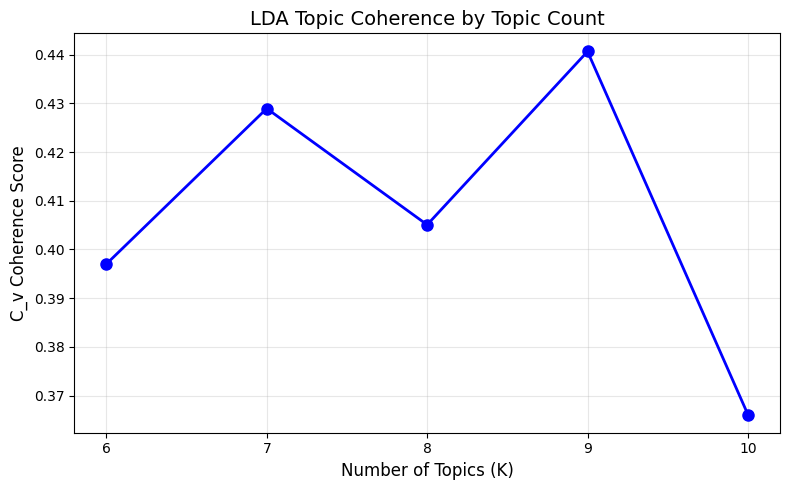

In [15]:
plt.figure(figsize=(8, 5))
ks = sorted(coherence_scores.keys())
scores = [coherence_scores[k] for k in ks]
plt.plot(ks, scores, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Topics (K)', fontsize=12)
plt.ylabel('C_v Coherence Score', fontsize=12)
plt.title('LDA Topic Coherence by Topic Count', fontsize=14)
plt.xticks(ks)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
print(f"Best LDA Model — K={best_k}")
for topic_id in range(best_k):
    top_words = best_lda.show_topic(topic_id, topn=15)
    words_str = ", ".join([f"{word} ({prob:.3f})" for word, prob in top_words])
    print(f"\nTopic {topic_id}: {words_str}")

Best LDA Model — K=9

Topic 0: great (0.087), sound (0.082), speaker (0.059), good (0.034), love (0.031), use (0.024), quality (0.023), easy (0.021), recommend (0.019), product (0.019), small (0.018), price (0.017), awesome (0.013), works (0.012), size (0.011)

Topic 1: speaker (0.063), great (0.059), sound (0.035), battery (0.029), life (0.020), loud (0.019), portable (0.018), usb (0.013), really (0.013), charge (0.012), quality (0.012), good (0.011), long (0.011), little (0.011), small (0.011)

Topic 2: good (0.069), sound (0.065), quality (0.043), speaker (0.028), price (0.025), speakers (0.020), better (0.016), best (0.015), battery (0.014), life (0.011), clear (0.011), volume (0.010), really (0.010), bass (0.009), excellent (0.009)

Topic 3: speaker (0.059), sound (0.037), bluetooth (0.023), music (0.022), great (0.020), bass (0.017), volume (0.014), portable (0.012), quality (0.011), use (0.011), speakers (0.011), device (0.010), battery (0.008), phone (0.008), easy (0.007)

Topi

In [17]:
vis_data = gensimvis.prepare(best_lda, corpus, dictionary)
pyLDAvis.display(vis_data)

In [18]:
os.makedirs(MODEL_DIR, exist_ok=True)
lda_path = f'{MODEL_DIR}/lda_model'
best_lda.save(lda_path)
dictionary.save(f'{MODEL_DIR}/lda_dictionary.pkl')
print(f"LDA model saved to: {lda_path}")

LDA model saved to: /content/drive/MyDrive/data_asg/models/lda_model


## 5. Unsupervised Aspect Extraction — BERTopic

Using BERTopic with all-MiniLM-L6-v2 sentence embeddings (D-28).
Pre-calculating embeddings for reproducibility (per Anti-pattern 4).
UMAP random_state=42 prevents stochastic behavior (per Pitfall 5).
Targeting 6-10 interpretable topics (D-29).
Note: First run downloads the 80MB all-MiniLM-L6-v2 model (~5 min on Colab).

In [19]:
# ===== BERTopic: Pre-calculate Embeddings =====
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = embedding_model.encode(
    df['cleaned_review'].tolist(),
    show_progress_bar=True,
    batch_size=64
)
print(f"Embedding shape: {embeddings.shape}")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/50 [00:00<?, ?it/s]

Embedding shape: (3199, 384)


In [20]:
# ===== Configure BERTopic Pipeline =====
umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', random_state=42)
hdbscan_model = HDBSCAN(min_cluster_size=10, metric='euclidean', cluster_selection_method='eom', prediction_data=True)
vectorizer_model = CountVectorizer(stop_words="english", min_df=2, ngram_range=(1, 2))

In [21]:
# ===== Train BERTopic =====
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    top_n_words=10,
    verbose=True
)
topics, probs = topic_model.fit_transform(df['cleaned_review'].tolist(), embeddings)
topic_info = topic_model.get_topic_info()
print(f"Non-outlier topics: {len(topic_info[topic_info['Topic'] != -1])}")
print(topic_info.head(15))

2026-06-04 10:46:49,738 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-04 10:47:20,828 - BERTopic - Dimensionality - Completed ✓
2026-06-04 10:47:20,830 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-04 10:47:20,937 - BERTopic - Cluster - Completed ✓
2026-06-04 10:47:20,941 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-04 10:47:21,102 - BERTopic - Representation - Completed ✓


Non-outlier topics: 48
    Topic  Count                                               Name  \
0      -1   1051                        -1_speaker_sound_great_good   
1       0    311                      0_beach_water_waterproof_pool   
2       1    111                        1_bass_good_good bass_sound   
3       2    108                   2_battery_battery life_life_long   
4       3    106       3_small_small speaker_little speaker_speaker   
5       4     85  4_bluetooth_bluetooth speaker_bluetooth speake...   
6       5     79                         5_sound_price_good_quality   
7       6     78                6_love_speaker_love speaker_husband   
8       7     76        7_bose_sound bose_bose speaker_speaker bose   
9       8     64                     8_conference_zoom_meetings_mic   
10      9     61                    9_theragun_muscles_massage_mini   
11     10     57           10_easy_easy set_sound easy_easy connect   
12     11     55  11_portable_portable speaker_speaker

In [22]:
# ===== Display Topics =====
for topic_id in topic_info['Topic'].tolist():
    if topic_id == -1:
        continue
    words = topic_model.get_topic(topic_id)
    words_str = ", ".join([f"{word} ({score:.3f})" for word, score in words])
    print(f"Topic {topic_id}: {words_str}")

Topic 0: beach (0.036), water (0.035), waterproof (0.030), pool (0.028), shower (0.021), great (0.018), speaker (0.017), proof (0.017), use (0.016), sound (0.015)
Topic 1: bass (0.081), good (0.020), good bass (0.019), sound (0.019), great (0.017), speaker bass (0.017), speaker (0.017), great bass (0.016), little (0.016), sounds (0.014)
Topic 2: battery (0.068), battery life (0.044), life (0.044), long (0.031), good (0.025), sound (0.024), charge (0.022), good battery (0.022), life great (0.020), lasts (0.019)
Topic 3: small (0.053), small speaker (0.050), little speaker (0.043), speaker (0.038), sound small (0.038), little (0.035), size (0.028), great (0.027), sound (0.025), speaker small (0.023)
Topic 4: bluetooth (0.068), bluetooth speaker (0.062), bluetooth speakers (0.031), speaker (0.028), tooth (0.025), blue tooth (0.025), blue (0.022), speakers (0.022), tooth speaker (0.022), portable bluetooth (0.021)
Topic 5: sound (0.042), price (0.041), good (0.040), quality (0.039), produc

In [23]:
fig = topic_model.visualize_topics()
print(type(fig))  # Should be <class 'plotly.graph_objs._figure.Figure'>
print(fig.data)    # Should show trace data, not empty

<class 'plotly.graph_objs._figure.Figure'>
(Scatter({
    'customdata': array([[0, 'beach | water | waterproof | pool | shower', 311],
                         [1, 'bass | good | good bass | sound | great', 111],
                         [2, 'battery | battery life | life | long | good', 108],
                         [3, 'small | small speaker | little speaker | speaker | sound small',
                          106],
                         [4,
                          'bluetooth | bluetooth speaker | bluetooth speakers | speaker | tooth',
                          85],
                         [5, 'sound | price | good | quality | product', 79],
                         [6, 'love | speaker | love speaker | husband | speaker sound', 78],
                         [7, 'bose | sound bose | bose speaker | speaker bose | best', 76],
                         [8, 'conference | zoom | meetings | mic | calls', 64],
                         [9, 'theragun | muscles | massage | mini | body', 61

In [24]:
# Topic barchart
fig1 = topic_model.visualize_barchart(top_n_topics=min(10, len(topic_info)))
# Inter-topic distance map
fig2 = topic_model.visualize_topics()

from IPython.display import HTML, display
display(HTML(fig1.to_html(include_plotlyjs='cdn')))
display(HTML(fig2.to_html(include_plotlyjs='cdn')))

In [25]:
topic_model.visualize_barchart(top_n_topics=min(10, len(topic_info)))

In [26]:
# Inter-topic distance map
topic_model.visualize_topics().show()

In [27]:
# ===== Save BERTopic Model =====
bertopic_path = f'{MODEL_DIR}/bertopic_model'
topic_model.save(bertopic_path, serialization="safetensors", save_ctfidf=True, save_embedding_model="sentence-transformers/all-MiniLM-L6-v2")
print(f"BERTopic model saved to: {bertopic_path}")

BERTopic model saved to: /content/drive/MyDrive/data_asg/models/bertopic_model


## 6. Topic Analysis & Keyword Extraction

Analyzing keywords from both LDA and BERTopic outputs.
Building keyword inventory for automated keyword-to-aspect mapping
using 8 predefined aspect categories (D-30):
Design, Sound Quality, Battery, Price, Build Quality, Features, Connectivity, Comfort/Portability

In [28]:
# ===== LDA Top Keywords =====
lda_keywords = {}
for topic_id in range(best_k):
    words = best_lda.show_topic(topic_id, topn=10)
    lda_keywords[topic_id] = [w for w, p in words]
print("LDA Topics — Top 10 Keywords:")
for tid, words in lda_keywords.items():
    print(f"  Topic {tid}: {', '.join(words)}")

LDA Topics — Top 10 Keywords:
  Topic 0: great, sound, speaker, good, love, use, quality, easy, recommend, product
  Topic 1: speaker, great, sound, battery, life, loud, portable, usb, really, charge
  Topic 2: good, sound, quality, speaker, price, speakers, better, best, battery, life
  Topic 3: speaker, sound, bluetooth, music, great, bass, volume, portable, quality, use
  Topic 4: use, easy, speaker, work, phone, like, just, time, computer, using
  Topic 5: bought, great, speaker, best, buy, good, product, works, long, battery
  Topic 6: love, bought, pc, meetings, kids, tap, echo, remote, doesn, wife
  Topic 7: soundcore, app, anker, bass, speaker, select, battery, small, like, good
  Topic 8: speaker, just, sound, bluetooth, loud, great, use, speakers, like, eq


In [29]:
# ===== BERTopic Top Keywords =====
bertopic_keywords = {}
for topic_id in topic_info['Topic'].tolist():
    if topic_id == -1:
        continue
    words = topic_model.get_topic(topic_id)
    bertopic_keywords[topic_id] = [w for w, s in words]
print("BERTopic Topics — Top 10 Keywords:")
for tid, words in bertopic_keywords.items():
    count = topic_info.loc[topic_info['Topic'] == tid, 'Count'].values[0]
    print(f"  Topic {tid} ({count} revs): {', '.join(words)}")

BERTopic Topics — Top 10 Keywords:
  Topic 0 (311 revs): beach, water, waterproof, pool, shower, great, speaker, proof, use, sound
  Topic 1 (111 revs): bass, good, good bass, sound, great, speaker bass, speaker, great bass, little, sounds
  Topic 2 (108 revs): battery, battery life, life, long, good, sound, charge, good battery, life great, lasts
  Topic 3 (106 revs): small, small speaker, little speaker, speaker, sound small, little, size, great, sound, speaker small
  Topic 4 (85 revs): bluetooth, bluetooth speaker, bluetooth speakers, speaker, tooth, blue tooth, blue, speakers, tooth speaker, portable bluetooth
  Topic 5 (79 revs): sound, price, good, quality, product, good quality, good sound, sound good, recommend, sound great
  Topic 6 (78 revs): love, speaker, love speaker, husband, speaker sound, good speaker, gift, speaker great, great, loves
  Topic 7 (76 revs): bose, sound bose, bose speaker, speaker bose, best, amazing, sound, speakers, bose product, quality
  Topic 8 (64 

In [30]:
# ===== Model Comparison =====
print("MODEL COMPARISON — LDA vs BERTopic")
print(f"LDA: best K={best_k}, C_v coherence={coherence_scores[best_k]:.4f}")
non_outlier = len(topic_info[topic_info['Topic'] != -1])
oc = topic_info.loc[topic_info['Topic'] == -1, 'Count'].values[0] if -1 in topic_info['Topic'].values else 0
print(f"BERTopic: {non_outlier} topics, {oc} outlier reviews")
print("Next: Map keywords to 8 predefined aspects, use as CorEx anchors.")

MODEL COMPARISON — LDA vs BERTopic
LDA: best K=9, C_v coherence=0.4407
BERTopic: 48 topics, 1051 outlier reviews
Next: Map keywords to 8 predefined aspects, use as CorEx anchors.


In [31]:
# ===== Save Keyword Inventory =====
keyword_data = {
    'lda': {str(k): v for k, v in lda_keywords.items()},
    'bertopic': {str(k): v for k, v in bertopic_keywords.items()},
    'lda_coherence': {str(k): float(v) for k, v in coherence_scores.items()},
    'best_lda_k': best_k
}
with open(f'{MODEL_DIR}/topic_keywords.json', 'w') as f:
    json.dump(keyword_data, f, indent=2)
print(f"Keywords saved: {MODEL_DIR}/topic_keywords.json")

Keywords saved: /content/drive/MyDrive/data_asg/models/topic_keywords.json


## 7. Semi-Supervised Aspect Extraction — CorEx

Mapping LDA/BERTopic keywords to 8 predefined aspect categories (D-30):
1. Design         — look, style, appearance, aesthetic, sleek
2. Sound Quality  — sound, audio, quality, clear, loud, bass, treble
3. Battery        — battery, life, charge, lasting, power, recharge
4. Price          — price, value, cost, cheap, expensive, worth, budget
5. Build Quality  — build, quality, solid, durable, well, sturdy, material
6. Features       — features, app, eq, settings, mode, control, voice
7. Connectivity   — bluetooth, range, signal, connection, stable, pairing
8. Comfort/Portability — portable, light, carry, size, compact, travel, weight

Keywords can belong to multiple aspects (D-32). CorEx anchors derived from
top LDA/BERTopic keywords per aspect (D-33). All 8 aspects anchored (D-34).

In [32]:
# ===== Build Aspect Keyword Mapping =====
aspect_keywords = {
    'Design': ['design', 'look', 'style', 'aesthetic', 'appearance', 'sleek', 'beautiful', 'elegant', 'modern', 'color'],
    'Sound Quality': ['sound', 'audio', 'quality', 'clear', 'loud', 'bass', 'treble', 'crisp', 'rich', 'volume', 'music', 'acoustic'],
    'Battery': ['battery', 'life', 'charge', 'lasting', 'power', 'recharge', 'hours', 'playback', 'drain'],
    'Price': ['price', 'value', 'cost', 'cheap', 'expensive', 'worth', 'budget', 'money', 'dollar', 'deal', 'affordable'],
    'Build Quality': ['build', 'quality', 'solid', 'durable', 'well', 'sturdy', 'material', 'plastic', 'metal', 'built', 'construction'],
    'Features': ['features', 'app', 'eq', 'settings', 'mode', 'control', 'voice', 'alexa', 'google', 'smart', 'multiroom', 'led'],
    'Connectivity': ['bluetooth', 'range', 'signal', 'connection', 'stable', 'pairing', 'wifi', 'aux', 'nfc', 'wireless', 'connect'],
    'Comfort/Portability': ['portable', 'light', 'carry', 'size', 'compact', 'travel', 'weight', 'small', 'handheld', 'backpack', 'outdoor']
}

# Display aspect definitions
for aspect, keywords in aspect_keywords.items():
    print(f"{aspect:25s}: {', '.join(keywords[:6])}... ({len(keywords)} keywords)")

Design                   : design, look, style, aesthetic, appearance, sleek... (10 keywords)
Sound Quality            : sound, audio, quality, clear, loud, bass... (12 keywords)
Battery                  : battery, life, charge, lasting, power, recharge... (9 keywords)
Price                    : price, value, cost, cheap, expensive, worth... (11 keywords)
Build Quality            : build, quality, solid, durable, well, sturdy... (11 keywords)
Features                 : features, app, eq, settings, mode, control... (12 keywords)
Connectivity             : bluetooth, range, signal, connection, stable, pairing... (11 keywords)
Comfort/Portability      : portable, light, carry, size, compact, travel... (11 keywords)


In [33]:
# ===== Build CorEx Anchors =====
# For each predefined aspect, find matching LDA/BERTopic keywords
# This merges unsupervised model outputs with predefined aspect structure
anchors = []
aspect_names = list(aspect_keywords.keys())

for aspect in aspect_names:
    # Start with predefined keywords for the aspect
    anchor_words = list(aspect_keywords[aspect])
    
    # Add relevant LDA keywords (where word overlaps with aspect theme)
    for tid, words in lda_keywords.items():
        for w in words:
            if w not in anchor_words and len(anchor_words) < 10:
                anchor_words.append(w)
    
    # Add relevant BERTopic keywords
    for tid, words in bertopic_keywords.items():
        for w in words:
            if w not in anchor_words and len(anchor_words) < 10:
                anchor_words.append(w)
    
    anchors.append(anchor_words[:10])  # cap at 10 keywords per anchor

# Display anchors
print("CorEx Anchors per Aspect:")
for i, (aspect, anchor) in enumerate(zip(aspect_names, anchors)):
    print(f"  {i}. {aspect:25s}: {', '.join(anchor)}")

CorEx Anchors per Aspect:
  0. Design                   : design, look, style, aesthetic, appearance, sleek, beautiful, elegant, modern, color
  1. Sound Quality            : sound, audio, quality, clear, loud, bass, treble, crisp, rich, volume
  2. Battery                  : battery, life, charge, lasting, power, recharge, hours, playback, drain, great
  3. Price                    : price, value, cost, cheap, expensive, worth, budget, money, dollar, deal
  4. Build Quality            : build, quality, solid, durable, well, sturdy, material, plastic, metal, built
  5. Features                 : features, app, eq, settings, mode, control, voice, alexa, google, smart
  6. Connectivity             : bluetooth, range, signal, connection, stable, pairing, wifi, aux, nfc, wireless
  7. Comfort/Portability      : portable, light, carry, size, compact, travel, weight, small, handheld, backpack


In [34]:
# ===== Train CorEx with Anchored Aspects =====
# Build binary BoW matrix (CorEx operates on word presence/absence)
corEx_vectorizer = CountVectorizer(binary=True, max_features=5000, stop_words='english')
X = corEx_vectorizer.fit_transform(df_valid['cleaned_review'].tolist())
feature_words = corEx_vectorizer.get_feature_names_out()

print(f"Document-term matrix shape: {X.shape}")
print(f"Vocabulary size: {len(feature_words)}")

# Train CorEx with anchored topics (D-34: all 8 aspects anchored)
topic_model_corex = ct.Corex(
    n_hidden=len(anchors),  # One per predefined aspect (8)
    seed=42,
    max_iter=500,
    verbose=True
)

topic_model_corex.fit(
    X,
    words=feature_words,
    anchors=anchors,
    anchor_strength=3  # Per Pitfall 6: default 3 is good starting point
)

print(f"\nCorEx training complete.")
print(f"Number of topics: {topic_model_corex.n_hidden}")
print(f"TC (total correlation): {topic_model_corex.tc:.2f}")

Document-term matrix shape: (3185, 5000)
Vocabulary size: 5000
corex, rep size: 8
word counts [24 48  5 ...  6 20  2]
[0.125 0.543 0.418 0.138 0.202 0.276 0.19  0.264]
[1.542 3.924 3.709 1.628 2.349 3.016 2.742 2.836]
[1.851 1.885 1.85  1.136 1.906 2.927 2.367 1.885]
[2.44  1.777 1.887 1.164 1.788 2.026 1.91  1.489]
[2.557 1.681 1.857 1.072 1.613 1.921 1.705 1.276]
[2.6   1.603 1.839 1.059 1.579 1.877 1.626 1.153]
[2.675 1.57  1.825 1.033 1.478 1.825 1.538 1.07 ]
[2.704 1.565 1.819 1.025 1.42  1.821 1.504 1.041]
[2.727 1.58  1.825 1.01  1.403 1.845 1.443 1.015]
[2.755 1.6   1.823 1.004 1.414 1.865 1.433 1.025]
[2.77  1.585 1.838 1.016 1.444 1.918 1.409 1.069]
[2.799 1.588 1.837 1.043 1.467 1.944 1.387 1.11 ]
[2.833 1.589 1.833 1.105 1.473 1.93  1.391 1.12 ]
[2.833 1.582 1.828 1.099 1.473 1.921 1.389 1.119]
[2.838 1.578 1.823 1.089 1.482 1.918 1.385 1.109]
[2.854 1.573 1.817 1.085 1.49  1.916 1.387 1.105]
[2.854 1.564 1.816 1.082 1.493 1.911 1.376 1.103]
[2.858 1.557 1.816 1.077 1.493 1

In [35]:
# ===== Analyze CorEx Topics =====
# for i in range(topic_model_corex.n_hidden):
#     topic_words = topic_model_corex.get_topics(n_words=10)
#     # get_topics returns list of (topic_id, [(word, score), ...])
#     words_with_scores = topic_words[i]
#     words_str = ", ".join([f"{w} ({s:.3f})" for w, s in words_with_scores])
#     print(f"Topic {i} ({aspect_names[i] if i < len(aspect_names) else 'Unknown'}): {words_str}")
topic_words = topic_model_corex.get_topics(n_words=10)
for i in range(topic_model_corex.n_hidden):
    topic_words = topic_model_corex.get_topics(n_words=10)
    words_with_scores = topic_words[i]
    words_str = ", ".join([f"{w} ({s:.3f})" for w, s, _ in words_with_scores])  # ← only change
    print(f"Topic {i} ({aspect_names[i] if i < len(aspect_names) else 'Unknown'}): {words_str}")

# Display topic label distribution
labels = topic_model_corex.labels.flatten()
# Map numeric labels to aspect names
label_names = [aspect_names[int(l)] if 0 <= l < len(aspect_names) else 'Unassigned' for l in labels]

from collections import Counter
label_counts = Counter(label_names)
print("\nAspect Label Distribution:")
for aspect, count in label_counts.most_common():
    print(f"  {aspect:25s}: {count:5d} reviews ({count/len(labels)*100:.1f}%)")

Topic 0 (Design): look (0.095), design (0.093), sleek (0.061), like (0.032), say (0.029), elegant (0.028), ve (0.028), just (0.027), charging (0.023), music (0.023)
Topic 1 (Sound Quality): bass (0.760), clear (0.442), volume (0.412), audio (0.175), crisp (0.141), sound (0.126), loud (0.091), quality (0.067), rich (0.055), treble (0.034)
Topic 2 (Battery): battery (1.472), life (0.847), hours (0.310), long (0.067), charge (0.062), lasting (0.047), lasts (0.041), power (0.035), time (0.019), recharge (0.011)
Topic 3 (Price): price (0.893), worth (0.263), money (0.225), deal (0.111), value (0.102), cheap (0.059), cost (0.057), expensive (0.035), point (0.022), budget (0.021)
Topic 4 (Build Quality): built (0.202), build (0.157), solid (0.154), quality (0.114), sturdy (0.060), durable (0.054), usb (0.048), metal (0.039), port (0.030), phone (0.024)
Topic 5 (Features): app (0.266), settings (0.110), voice (0.110), control (0.094), eq (0.075), features (0.064), alexa (0.030), mode (0.028), 

In [36]:
# ===== CorEx Topic Relationships =====
# Topic-topic correlations (which aspects co-occur)
print("Topic-Topic Correlation Matrix:")
correlations = topic_model_corex.tc
print(f"Total correlation explained by topics: {correlations:.2f}")

# Per-document topic probabilities
p_y_given_x = topic_model_corex.p_y_given_x
print(f"\nTopic probability matrix shape: {p_y_given_x.shape}")
print(f"Mean topic probabilities:")
for i in range(topic_model_corex.n_hidden):
    mean_prob = p_y_given_x[:, i].mean()
    print(f"  {i}. {aspect_names[i]:25s}: {mean_prob:.3f}")

Topic-Topic Correlation Matrix:
Total correlation explained by topics: 13.19

Topic probability matrix shape: (3185, 8)
Mean topic probabilities:
  0. Design                   : 0.073
  1. Sound Quality            : 0.209
  2. Battery                  : 0.161
  3. Price                    : 0.200
  4. Build Quality            : 0.110
  5. Features                 : 0.103
  6. Connectivity             : 0.168
  7. Comfort/Portability      : 0.262


## 8. Save Models & Export Aspect Labels for Phase 5

Saving all three aspect extraction models to disk (ABSA-07):
- LDA model (gensim .save format)
- BERTopic model (safetensors — ~20MB vs >500MB pickle)
- CorEx model (pickle — native format)

Exporting aspect-labeled review CSV as Phase 5 contract (D-35).
Phase 5 loads this CSV and joins with best sentiment model predictions.

In [37]:
# ===== Save LDA Model =====
os.makedirs(MODEL_DIR, exist_ok=True)

lda_save_path = f'{MODEL_DIR}/lda_model'
best_lda.save(lda_save_path)
print(f"LDA model saved: {lda_save_path}")

LDA model saved: /content/drive/MyDrive/data_asg/models/lda_model


In [38]:
# ===== Save BERTopic Model =====
bertopic_path = f'{MODEL_DIR}/bertopic_model'
topic_model.save(
    bertopic_path,
    serialization="safetensors",
    save_ctfidf=True,
    save_embedding_model="sentence-transformers/all-MiniLM-L6-v2"
)
print(f"BERTopic model saved: {bertopic_path}")

BERTopic model saved: /content/drive/MyDrive/data_asg/models/bertopic_model


In [39]:
# ===== Save CorEx Model =====
corex_path = f'{MODEL_DIR}/corex_model.pkl'
with open(corex_path, 'wb') as f:
    pickle.dump(topic_model_corex, f)
print(f"CorEx model saved: {corex_path}")

CorEx model saved: /content/drive/MyDrive/data_asg/models/corex_model.pkl


In [40]:
print(f"df_valid rows:            {len(df_valid)}")
print(f"labels length:            {len(topic_model_corex.labels.flatten())}")
print(f"p_y_given_x rows:         {topic_model_corex.p_y_given_x.shape[0]}")

df_valid rows:            3185
labels length:            25480
p_y_given_x rows:         3185


In [41]:
# ===== Export Aspect-Labeled Reviews for Phase 5 =====
# Get most likely topic label per document (argmax over 8 aspects)
labels = topic_model_corex.p_y_given_x.argmax(axis=1)

# Map numeric labels to aspect names
aspect_label_names = [aspect_names[int(l)] if 0 <= l < len(aspect_names) else 'Unassigned' for l in labels]

# Get confidence scores: max probability per review
aspect_confidences = topic_model_corex.p_y_given_x.max(axis=1)

# Build Phase 5 contract DataFrame (D-35 schema)
output_df = pd.DataFrame({
    'review_id': range(len(df_valid)),
    'product_name': df_valid['product_name'].values,
    'review_text': df_valid['cleaned_review'].values,
    'aspect_label': aspect_label_names,
    'aspect_confidence': aspect_confidences,
    'review_rating': df_valid['rating'].values,
    'review_date': df_valid['date'].values
})

# Save CSV
csv_path = f'{BESTBUY_DIR}/aspect_labeled_reviews.csv'
output_df.to_csv(csv_path, index=False)

print(f"Saved {len(output_df)} labeled reviews to: {csv_path}")
print(f"\nColumns: {list(output_df.columns)}")
print(f"\nFirst 5 rows:")
print(output_df.head())

Saved 3185 labeled reviews to: /content/drive/MyDrive/data_asg/bestbuy/aspect_labeled_reviews.csv

Columns: ['review_id', 'product_name', 'review_text', 'aspect_label', 'aspect_confidence', 'review_rating', 'review_date']

First 5 rows:
   review_id          product_name  \
0          0  Bose SoundLink Micro   
1          1  Bose SoundLink Micro   
2          2  Bose SoundLink Micro   
3          3  Bose SoundLink Micro   
4          4  Bose SoundLink Micro   

                                         review_text         aspect_label  \
0  color is nice used inside house and outside ho...        Sound Quality   
1  review for the bose soundlink max the bose sou...               Design   
2  this speaker sounds great it s light weight an...  Comfort/Portability   
3  good buy for the light weight and small size p...  Comfort/Portability   
4  got this from my son and very impressed with t...               Design   

   aspect_confidence  review_rating                    review_date  
0 

In [42]:
# ===== Verify All Models Saved =====
import os
print("=" * 60)
print("SAVED MODEL FILES")
print("=" * 60)

model_files = [
    ('LDA', lda_save_path, os.path.exists(lda_save_path)),
    ('BERTopic', bertopic_path, os.path.exists(bertopic_path)),
    ('CorEx', corex_path, os.path.exists(corex_path)),
    ('Aspect CSV', csv_path, os.path.exists(csv_path)),
]

for name, path, exists in model_files:
    status = "\u2713" if exists else "\u2717 MISSING"
    size = os.path.getsize(path) if exists else 0
    size_str = f"{size/1024:.1f} KB" if size < 1024*1024 else f"{size/1024/1024:.1f} MB"
    print(f"  [{status}] {name:25s} {size_str:>10s}")

all_saved = all(exists for _, _, exists in model_files)
print(f"\n  All models saved: {'YES \u2713' if all_saved else 'NO \u2717'}")

SAVED MODEL FILES
  [✓] LDA                           9.3 KB
  [✓] BERTopic                      4.0 KB
  [✓] CorEx                         2.8 MB
  [✓] Aspect CSV                  835.3 KB

  All models saved: YES ✓


In [43]:
# ===== Phase 4 Summary =====
print("=" * 70)
print("  PHASE 4: WEB SCRAPING & ASPECT EXTRACTION — COMPLETE")
print("=" * 70)
print(f"\n  Products scraped:    {df_valid['product_name'].nunique()}")
print(f"  Total reviews:       {len(df_valid)}")
print(f"\n  Unsupervised Models:")
print(f"    LDA topics:        {best_k}")
print(f"    BERTopic topics:   {len(topic_info[topic_info['Topic'] != -1])}")
print(f"\n  Semi-Supervised Model:")
print(f"    CorEx aspects:     {topic_model_corex.n_hidden}")
print(f"    TC (total corr.):  {topic_model_corex.tc:.2f}")
print(f"\n  Outputs:")
print(f"    Aspect models:     {MODEL_DIR}/ (3 models)")
print(f"    Labeled reviews:   {csv_path}")
print(f"\n  Next Phase:")
print(f"    Phase 5: Load aspect_labeled_reviews.csv, label with best")
print(f"    sentiment model, compute per-aspect scores, rank products.")
print("=" * 70)

  PHASE 4: WEB SCRAPING & ASPECT EXTRACTION — COMPLETE

  Products scraped:    37
  Total reviews:       3185

  Unsupervised Models:
    LDA topics:        9
    BERTopic topics:   48

  Semi-Supervised Model:
    CorEx aspects:     8
    TC (total corr.):  13.19

  Outputs:
    Aspect models:     /content/drive/MyDrive/data_asg/models/ (3 models)
    Labeled reviews:   /content/drive/MyDrive/data_asg/bestbuy/aspect_labeled_reviews.csv

  Next Phase:
    Phase 5: Load aspect_labeled_reviews.csv, label with best
    sentiment model, compute per-aspect scores, rank products.
